# 02 — Animal Comparison

Expert (uniform) psychometric for an example WT vs HET, broken down by session / trial condition.

## Setup

In [1]:
%matplotlib inline
from shared_setup import *
from analysis.phase import compute_phase

experiment, info = load_data()
print(f"Mode: {info['mode']}")

Loaded snapshot: 22 animals, 1185 sessions (exported 2026-06-09)
Mode: snapshot


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/notebooks/shared_setup.py:193: UserWarning: Snapshot is 215h old (exported 2026-06-09T12:49:35.485965+00:00). Re-export if new sessions have been collected.
  experiment, meta = load_snapshot(


## Genotype groups

In [2]:
# WT = light-delivery controls; HET = active-inhibition opto animals.
# SS01-13 are HETs that predate the opto cohort, so they're excluded from the opto HET group.
NON_OPTO_IDS = ['SS01', 'SS02', 'SS03', 'SS04', 'SS05', 'SS06',
                'SS07', 'SS08', 'SS09', 'SS10', 'SS11', 'SS12', 'SS13']

WT_IDS, HET_IDS = [], []
for animal_id in experiment.animal_ids:
    genotype = experiment.get_animal(animal_id).genotype.upper()
    if genotype == 'WT':
        WT_IDS.append(animal_id)
    elif genotype == 'HET' and animal_id not in NON_OPTO_IDS:
        HET_IDS.append(animal_id)

print(f"WT:  {WT_IDS}")
print(f"HET: {HET_IDS}")

WT:  ['SS14', 'SS17', 'SS18', 'SS20']
HET: ['SS15', 'SS16', 'SS19', 'SS21', 'SS22', 'SS23']


In [3]:
wt_animal = experiment.get_animal(WT_IDS[0])
het_animal = experiment.get_animal(HET_IDS[0])
print(f"WT  {wt_animal.animal_id} ({wt_animal.genotype})")
print(f"HET {het_animal.animal_id} ({het_animal.genotype})")

WT  SS14 (wt)
HET SS15 (het)


## Uniform (expert) — compute per condition

`compute_phase(animal, 'uniform', cohort='opto')` returns three dicts — `clean`, `psyc`, `um` —
keyed by the six condition labels (`baseline`, `masking`, `all_opto`, `opto_off`, `opto_on`,
`post_opto`). A condition with no surviving sessions is `None` in all three. `min_accuracy=0.6`
applies a session-quality floor to every condition.

In [4]:
PRETTY = {
    'baseline':  'Last5 Sessions',
    'masking':   'Masking Sessions',
    'all_opto':  'Opto Sessions',
    'opto_off':  'Non-Opto Trials',
    'opto_on':   'Opto Trials',
    'post_opto': 'Post-Opto Trials',
}

clean_wt,  psyc_wt,  um_wt  = compute_phase(wt_animal,  'uniform', cohort='opto', min_accuracy=0.6)
clean_het, psyc_het, um_het = compute_phase(het_animal, 'uniform', cohort='opto', min_accuracy=0.6)

print(list(psyc_wt))

['baseline', 'masking', 'all_opto', 'opto_off', 'opto_on', 'post_opto']


## Compare one condition: WT vs HET

Change `condition` to step through the six labels. A condition with no surviving sessions
for either animal is skipped rather than plotted.

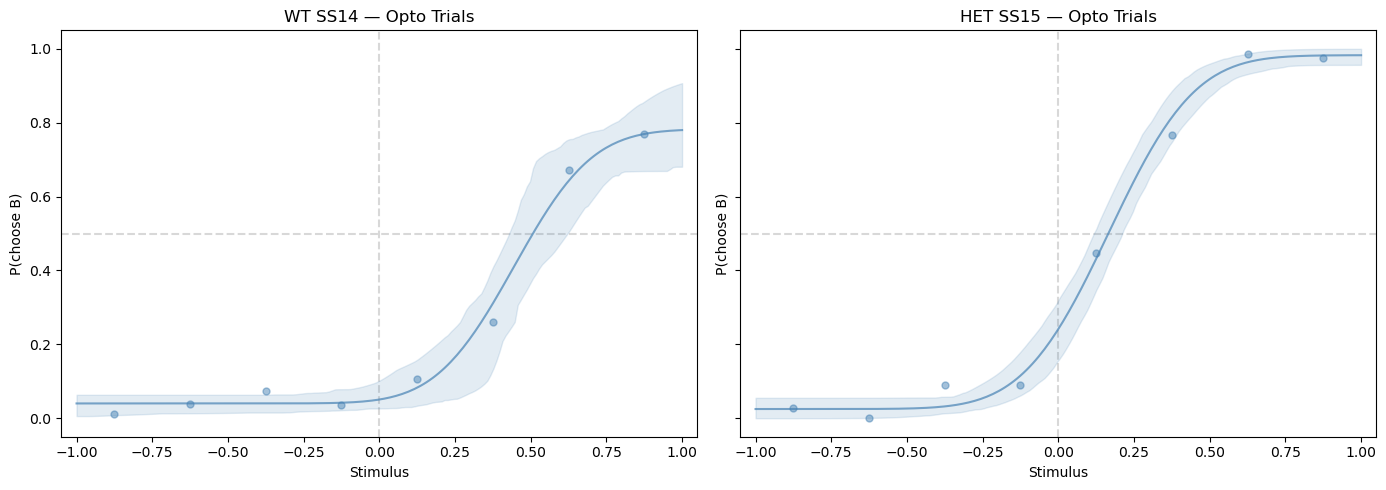

In [5]:
condition = 'opto_on'   # baseline | masking | all_opto | opto_off | opto_on | post_opto

if psyc_wt.get(condition) is None or psyc_het.get(condition) is None:
    missing = [g for g, p in [('WT', psyc_wt.get(condition)),
                              ('HET', psyc_het.get(condition))] if p is None]
    print(f"No surviving sessions for {condition!r}: {', '.join(missing)} — nothing to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    plot_psychometric(psyc_wt[condition],  ax=axes[0])
    plot_psychometric(psyc_het[condition], ax=axes[1])
    axes[0].set_title(f"WT {wt_animal.animal_id} — {PRETTY[condition]}")
    axes[1].set_title(f"HET {het_animal.animal_id} — {PRETTY[condition]}")
    plt.tight_layout(); plt.show()